# Topic 5 Example 5
## Circuit response to exponential input

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt

import sympy as sp
from sympy import Symbol, oo, integrate 
from sympy import lambdify, Symbol, integrate
print("Running Sympy:",sp.__version__)
ts = Symbol('t')

from ipywidgets import interactive
from IPython.display import HTML

from lcapy import Circuit, j, omega, s, exp, t, u, delta
from lcapy import R, C, L

def H(t):
    return np.heaviside(t, 1)

Running Sympy: 1.13.3


/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/lcapy/__init__.py:76: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


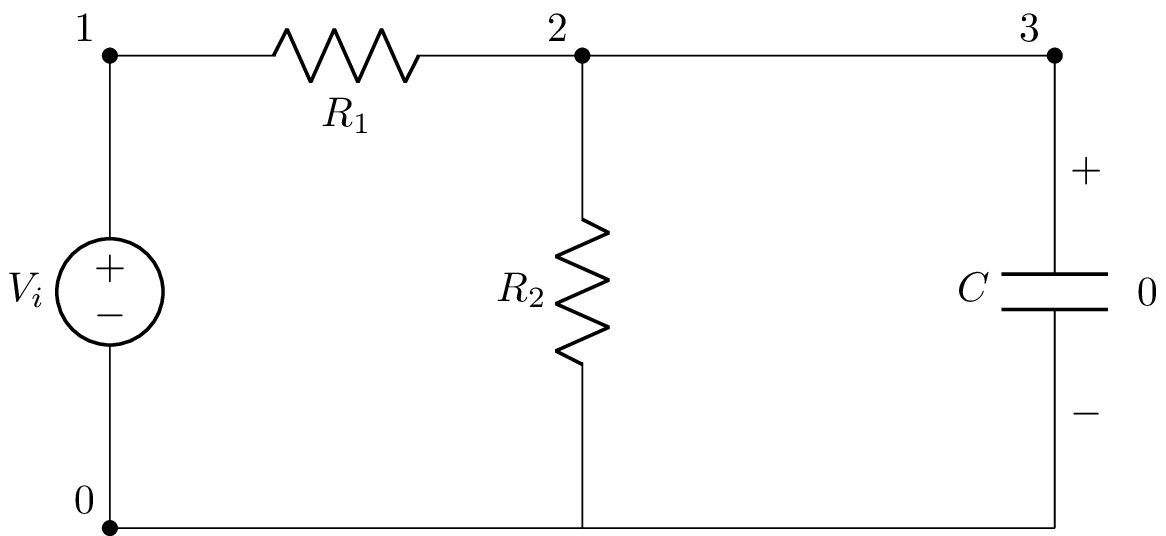

In [4]:
# Form circuit
RR1 = 1
RR2 = 2

cct2 = Circuit("""
Vi 1 0 ; down=2
R1 1 2 ; right=2
R2 2 0_2 ; down=2
W 2 3; right=2
C 3 0_3 C 0; down=2, , v=0
W 0 0_2; right
W 0_2 0_3; right""")

cct2.draw()

In [5]:
w = delta(t) # find step response
cct2a = cct2.subs({'Vi':w, 'R1': RR1, 'C':1, 'R2':RR2})

#find the impulse response
g_imp = cct2a.C.v(t)
g_imp

 -3⋅t      
 ─────     
   2       
ℯ     ⋅u(t)

In [6]:
w = u(t) # find step response
cct2a = cct2.subs({'Vi':w, 'R1': RR1, 'C':1, 'R2':RR2})

#Given the step response, find the impulse response
g_step = cct2a.C.v(t)
g_diff = sp.diff(g_step,t) # deriv of step response to get impulse  
g_diff # show impulse resp


⎛       -3⋅t ⎞                   
⎜       ─────⎟         -3⋅t      
⎜         2  ⎟         ─────     
⎜2   2⋅ℯ     ⎟           2       
⎜─ - ────────⎟⋅δ(t) + ℯ     ⋅u(t)
⎝3      3    ⎠                   

The extra impulse term in the differentiated step response is zero in the distribution sense. Since

$$
f(t)\delta(t)=f(0)\delta(t),
$$

we have

$$
\left(\frac{2}{3}-\frac{2e^{-3t/2}}{3}\right)\delta(t)
=\left(\frac{2}{3}-\frac{2}{3}\right)\delta(t)=0.
$$

Thus differentiating the step response gives the same impulse response,

$$
g_{\mathrm{imp}}(t)=e^{-3t/2}u(t).
$$


In [7]:
g_diff_sp = sp.expand(g_diff.expr)

delta_coeff = sp.simplify(g_diff_sp.coeff(sp.DiracDelta(t)))

# get the actual SymPy symbol inside delta_coeff
tsym = next(s for s in delta_coeff.free_symbols if s.name == "t")

print("actual symbol:", repr(tsym))
print("delta coefficient:", delta_coeff)
print("value at t=0:", sp.simplify(delta_coeff.subs(tsym, 0)))

g_imp_from_step = sp.simplify(g_diff_sp - delta_coeff*sp.DiracDelta(t))
g_imp_from_step


actual symbol: t
delta coefficient: 2/3 - 2*exp(-3*t/2)/3
value at t=0: 0


## Evaluate the Impulse and Step Responses

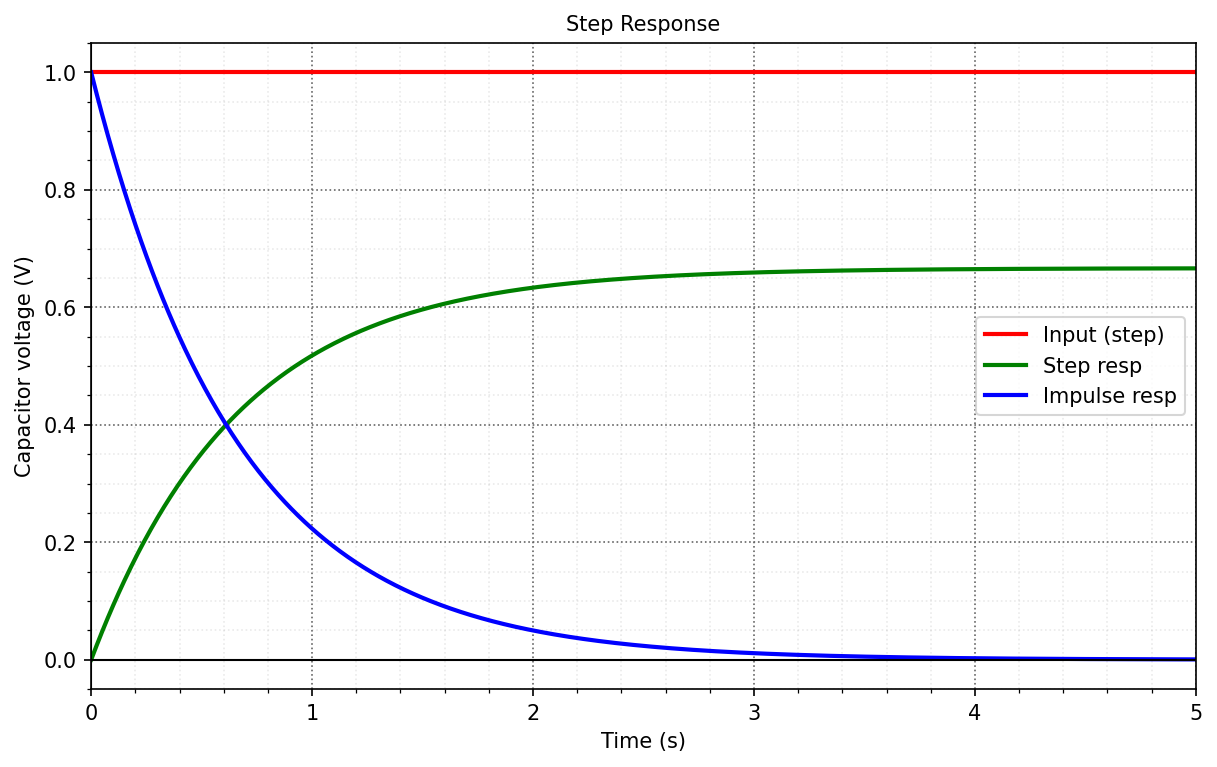

In [8]:
# find the voltage across the capacitor
tt = np.linspace(1e-12, 5, 1000)
Vgs = g_step.evaluate(tt) # step resp
Vg = g_imp.evaluate(tt) # impulse resp

fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Step Response')
ax.plot(tt, w.evaluate(tt), linewidth=2, color='red', label='Input (step)') 
ax.plot(tt, Vgs, linewidth=2, color='green', label='Step resp')
ax.plot(tt, Vg, linewidth=2, color='blue', label='Impulse resp')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Capacitor voltage (V)');
bm.nicegrid()
plt.xlim(0,5)
plt.legend()
plt.show()

## Now compute the full response to $w(t)$ and compare the 2 solutions found

In [9]:
from lcapy import exp, t
# Can apply the same technique to find 
wfull = exp(-t) * u(t)
cct2f = cct2.subs({'Vi':wfull, 'R1': RR1, 'C':1, 'R2':RR2})
Vcf = cct2f.C.v.evaluate(tt)

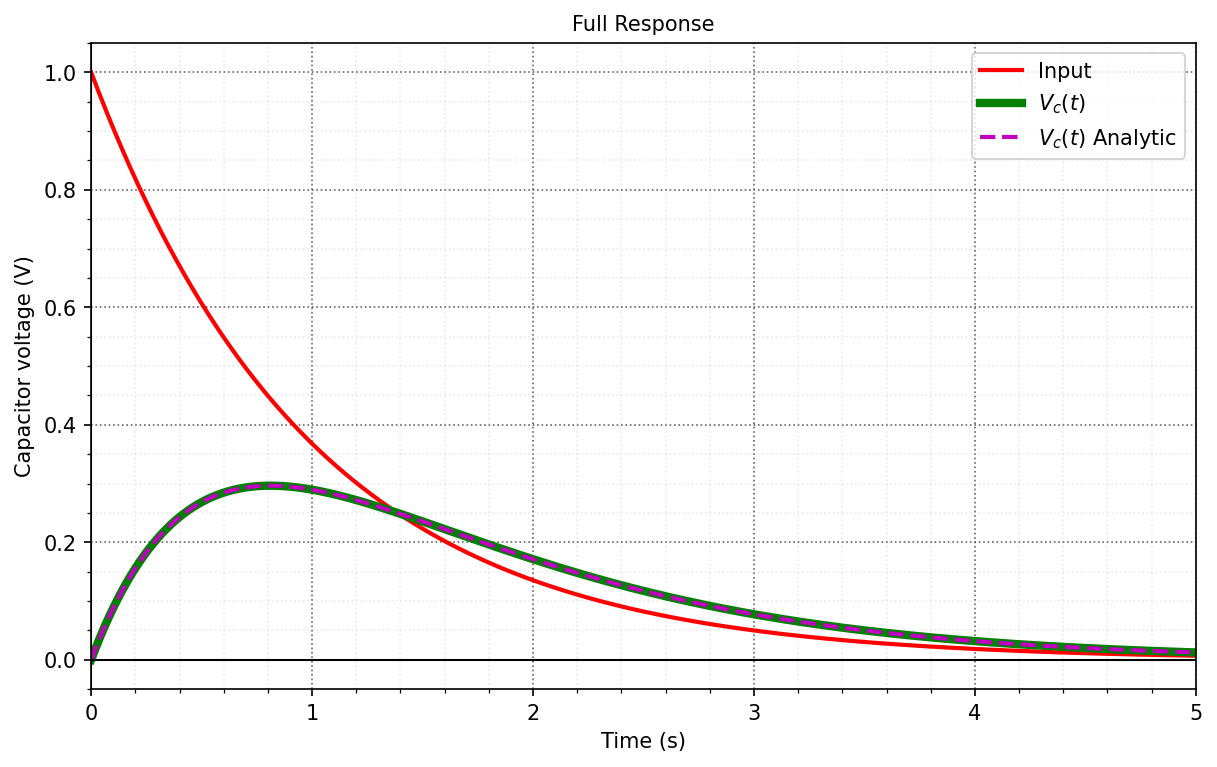

In [10]:
# Plot response to full input and compare to analytic

# compute quantities needed
Req = (1/RR1 + 1/RR2)
ReqC = Req * 1
# Expression given in notes for comparison
e_analytic = (2*(np.exp( -1 * tt) - np.exp( -1.5 * tt)))*H(tt) 

fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Full Response')
ax.plot(tt, cct2f.Vi.v.evaluate(tt), linewidth=2, color='red', label='Input')
ax.plot(tt, Vcf, linewidth=4, color='green', label='$V_c(t)$')
ax.plot(tt, e_analytic, 'm--',  linewidth=2, label='$V_c(t)$ Analytic')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Capacitor voltage (V)');
bm.nicegrid()
plt.legend()
plt.xlim(0,5)
plt.show()

## Compare with a Symbolic Convolution

In [11]:
def convolve(f, g, t, lower_limit=-oo, upper_limit=oo):
    tau = Symbol('__pick_a_name__', real=True)
    return integrate(f.subs(t, tau) * g.subs(t, t - tau), (tau, lower_limit, upper_limit))


In [12]:
f1 = sp.exp(-1.5*ts)*sp.Heaviside(ts) # impulse resp
f2 = sp.exp(-1*ts)*sp.Heaviside(ts) # input
f3 = convolve(f1, f2, ts, 0 , ts) # full response

lam_f1 = lambdify(ts, f1, modules=['numpy'])
lam_f2 = lambdify(ts, f2, modules=['numpy'])
lam_f3 = lambdify(ts, f3, modules=['numpy'])

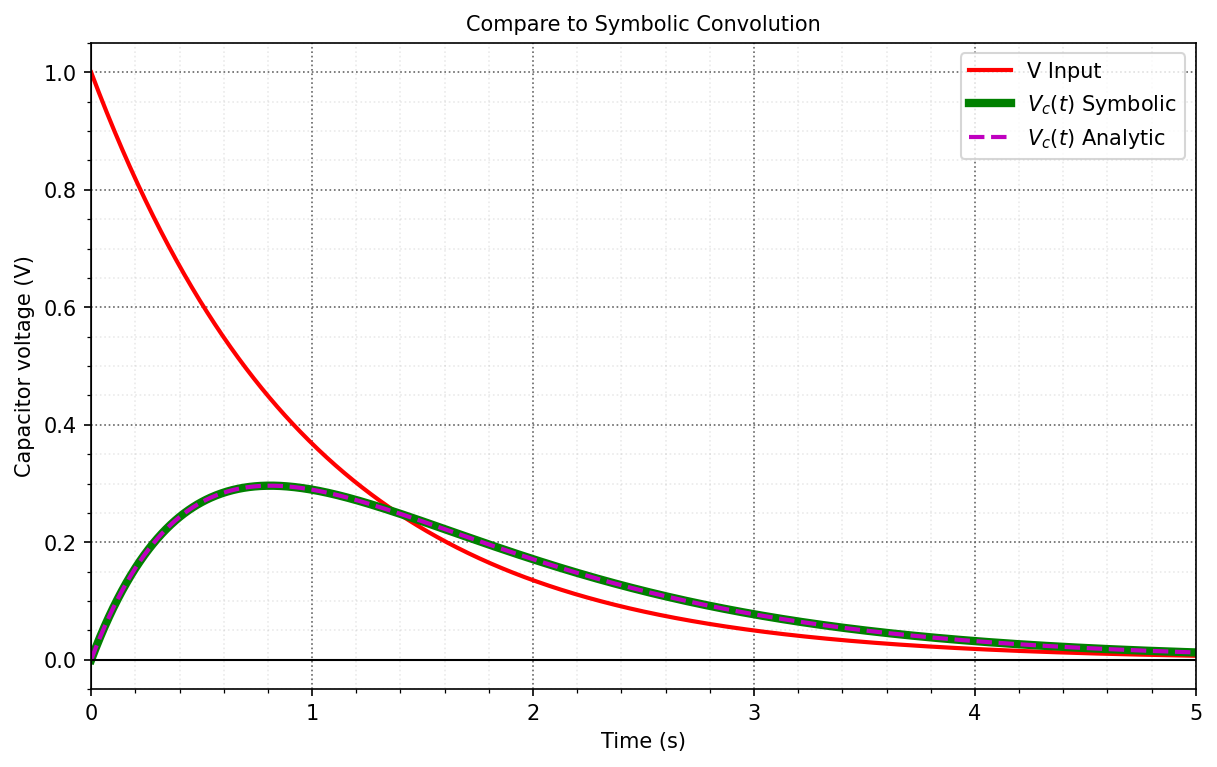

In [13]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt, lam_f2(tt),'r',label='V Input')
plt.plot(tt, lam_f3(tt),linewidth=4, ls='-', c='g', label='$V_c(t)$ Symbolic')
plt.plot(tt, e_analytic, 'm--', linewidth=2, label='$V_c(t)$ Analytic')

bm.nicegrid()
plt.legend()
plt.xlim(0,5)
plt.xlabel('Time (s)')
plt.ylabel('Capacitor voltage (V)')
plt.title('Compare to Symbolic Convolution')
plt.show()